In [22]:
import pandas as pd
import pypsa
import warnings


Add a network and set the hours of the year 2015 as snapshots in the network

In [23]:
network = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

network.set_snapshots(hours_in_2015.values)

network.add("Bus",
            "electricity bus")

network.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)

Add electricity demand data

In [24]:
# load electricity demand data
df_elec = pd.read_csv('data/electricity_demand.csv', sep=';', index_col=0) # in MWh
df_elec.index = pd.to_datetime(df_elec.index) #change index to datetime
country='FRA'
print(df_elec[country].head())

utc_time
2015-01-01 00:00:00+00:00    71077.0
2015-01-01 01:00:00+00:00    68774.0
2015-01-01 02:00:00+00:00    65695.0
2015-01-01 03:00:00+00:00    64020.0
2015-01-01 04:00:00+00:00    64195.0
Name: FRA, dtype: float64


In [25]:
# add load to the bus
network.add("Load",
            "load",
            bus="electricity bus",
            p_set=df_elec[country].values)

network.loads_t.p_set

name,load
snapshot,
2015-01-01 00:00:00,71077.0
2015-01-01 01:00:00,68774.0
2015-01-01 02:00:00,65695.0
2015-01-01 03:00:00,64020.0
2015-01-01 04:00:00,64195.0
...,...
2015-12-31 19:00:00,56712.0
2015-12-31 20:00:00,55066.0
2015-12-31 21:00:00,59420.0


Function for annuity factor, as this is used to calculate cost of investment in different technologies

In [26]:
def annuity(n,r):
    """ Calculate the annuity factor for an asset with lifetime n years and
    discount rate  r """

    if r > 0:
        return r/(1. - 1./(1.+r)**n)
    else:
        return 1/n


Capital cost for wind is assumed to be ??

Capital cost for solar is ??

Capital cost for nuclear is 3460 EUR/kWh and marginal cost is 6 EUR/MWh and co2 emission is 0

Capital cost for gas is ?? and marginal cost is ?? and co2 emission is ??

For nuclear it is assumed that it has to

In [27]:
# add the different carriers, gas emits CO2
network.add("Carrier", "gas", co2_emissions=0.19, overwrite=True) # in t_CO2/MWh_th
network.add("Carrier", "nuclear", overwrite=True) # no co2 emissions from nuclear
network.add("Carrier", "onshorewind", overwrite=True)
network.add("Carrier", "solar", overwrite=True)

# add onshore wind generator
df_onshorewind = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';', index_col=0)
df_onshorewind.index = pd.to_datetime(df_onshorewind.index)
CF_wind = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_onshorewind = annuity(30,0.07)*910000*(1+0.033) # in €/MW
network.add("Generator",
            "onshorewind",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="onshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_onshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind.values,
            overwrite=True)

# add solar PV generator
df_solar = pd.read_csv('data/pv_optimal.csv', sep=';', index_col=0)
df_solar.index = pd.to_datetime(df_solar.index)
CF_solar = df_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_solar = annuity(25,0.07)*425000*(1+0.03) # in €/MW
network.add("Generator",
            "solar",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="solar",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_solar,
            marginal_cost = 0,
            p_max_pu = CF_solar.values,
            overwrite=True)

# add OCGT (Open Cycle Gas Turbine) generator
capital_cost_OCGT = annuity(25,0.07)*560000*(1+0.033) # in €/MW
fuel_cost = 21.6 # in €/MWh_th
efficiency = 0.39 # MWh_elec/MWh_th
marginal_cost_OCGT = fuel_cost/efficiency # in €/MWh_el
network.add("Generator",
            "OCGT",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="gas",
            #p_nom_max=1000,
            capital_cost = capital_cost_OCGT,
            marginal_cost = marginal_cost_OCGT,
            overwrite=True)


# nuclear generator
capital_cost_nuclear = annuity(60,0.07)*3460*1000*(1+0.03)

network.add("Generator",
            "nuclear",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="nuclear",
            capital_cost=capital_cost_nuclear,
            marginal_cost=6,
            p_max_pu=1.0,
            p_min_pu=0.5, # Nuclear has an operational range of 50-100% capacity
            ramp_limit_up=0.15,   # 15% per hour
            ramp_limit_down=0.15,
            overwrite=True) # 15% per hour

In [28]:
network.generators_t.p_max_pu

name,onshorewind,solar
snapshot,,
2015-01-01 00:00:00,0.115,0.0
2015-01-01 01:00:00,0.121,0.0
2015-01-01 02:00:00,0.132,0.0
2015-01-01 03:00:00,0.129,0.0
2015-01-01 04:00:00,0.126,0.0
...,...,...
2015-12-31 19:00:00,0.252,0.0
2015-12-31 20:00:00,0.241,0.0
2015-12-31 21:00:00,0.216,0.0


In [29]:
network.optimize(solver_name='gurobi', solver_options={"OutputFlag": 0})

C:\Users\oscar\AppData\Local\Temp\ipykernel_19032\2266490682.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi', solver_options={"OutputFlag": 0})
Index(['electricity bus'], dtype='object', name='name')


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - OutputFlag: 0
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 296.12it/s]
INFO:linopy.io: Writing time: 0.25s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2733362


...

Reading time = 0.21 seconds


INFO:gurobipy:Reading time = 0.21 seconds


obj: 96362 rows, 35044 columns, 197295 nonzeros


INFO:gurobipy:obj: 96362 rows, 35044 columns, 197295 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 96362 duals
Objective: 2.02e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Generator-p-ramp_limit_up, Generator-p-ramp_limit_down were not assigned to the network.


('ok', 'optimal')

In [30]:
print(network.objective/1000000) #in 10^6 €

20235.444772596187


In [31]:
print(network.objective/network.loads_t.p.sum()) # EUR/MWh

name
load    42.940421
dtype: float64


In [32]:
network.generators.p_nom_opt # in MW

name
onshorewind     7854.838710
solar            746.351321
OCGT           36014.790323
nuclear        51072.129032
Name: p_nom_opt, dtype: float64

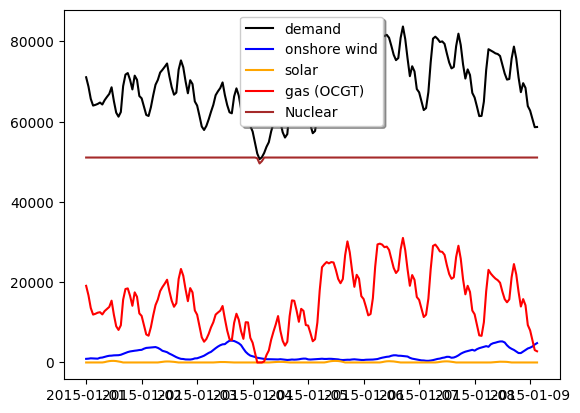

In [33]:
import matplotlib.pyplot as plt

plt.plot(network.loads_t.p['load'][0:196], color='black', label='demand')
plt.plot(network.generators_t.p['onshorewind'][0:196], color='blue', label='onshore wind')
plt.plot(network.generators_t.p['solar'][0:196], color='orange', label='solar')
plt.plot(network.generators_t.p['OCGT'][0:196], color='red', label='gas (OCGT)')
plt.plot(network.generators_t.p['nuclear'][0:196], color='brown', label='Nuclear')

plt.legend(fancybox=True, shadow=True, loc='best')

In [34]:
capital_cost_nuclear/capital_cost_onshorewind

3.3509508486969346

Text(0.5, 1.07, 'Electricity mix')

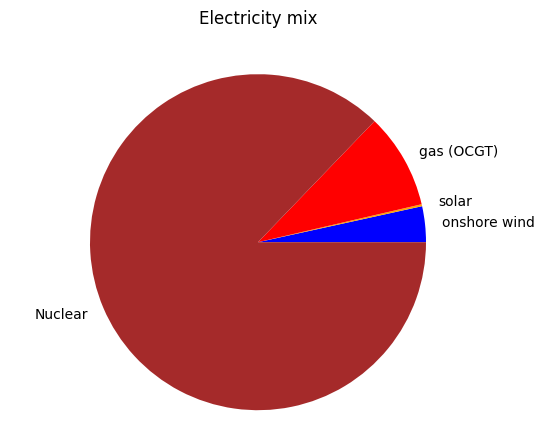

In [35]:
labels = ['onshore wind',
          'solar',
          'gas (OCGT)',
          'Nuclear']
sizes = [network.generators_t.p['onshorewind'].sum(),
         network.generators_t.p['solar'].sum(),
         network.generators_t.p['OCGT'].sum(),
         network.generators_t.p['nuclear'].sum()]

colors=['blue', 'orange', 'red', 'brown']

plt.pie(sizes,
        colors=colors,
        labels=labels,
        wedgeprops={'linewidth':0})
plt.axis('equal')

plt.title('Electricity mix', y=1.07)

In [36]:
co2_limit=1000000 #tonCO2
network.add("GlobalConstraint",
            "co2_limit",
            type="primary_energy",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=co2_limit)

network.optimize(solver_name='gurobi', solver_options={"OutputFlag": 0})

C:\Users\oscar\AppData\Local\Temp\ipykernel_19032\2078185863.py:9: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi', solver_options={"OutputFlag": 0})
Index(['electricity bus'], dtype='object', name='name')


Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - OutputFlag: 0
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 127.18it/s]
INFO:linopy.io: Writing time: 0.13s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2733362


...

Reading time = 0.20 seconds


INFO:gurobipy:Reading time = 0.20 seconds


obj: 96363 rows, 35044 columns, 206055 nonzeros


INFO:gurobipy:obj: 96363 rows, 35044 columns, 206055 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35044 primals, 96363 duals
Objective: 2.27e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Generator-p-ramp_limit_up, Generator-p-ramp_limit_down were not assigned to the network.


('ok', 'optimal')

In [37]:
network.generators.p_nom_opt #in MW

name
onshorewind    48289.823968
solar          14600.032947
OCGT           24705.929154
nuclear        58598.000000
Name: p_nom_opt, dtype: float64

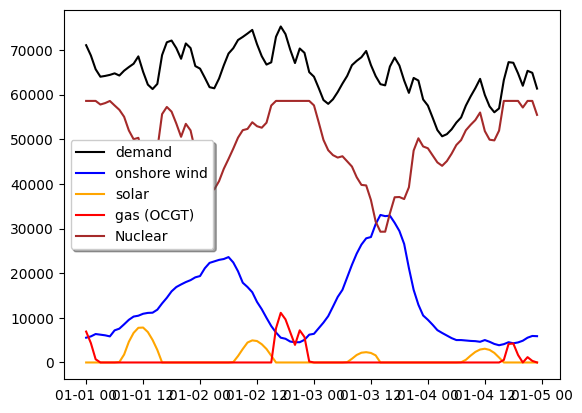

In [38]:
plt.plot(network.loads_t.p['load'][0:96], color='black', label='demand')
plt.plot(network.generators_t.p['onshorewind'][0:96], color='blue', label='onshore wind')
plt.plot(network.generators_t.p['solar'][0:96], color='orange', label='solar')
plt.plot(network.generators_t.p['OCGT'][0:96], color='red', label='gas (OCGT)')
plt.plot(network.generators_t.p['nuclear'][0:96], color='brown', label='Nuclear')
plt.legend(fancybox=True, shadow=True, loc='best')

Text(0.5, 1.07, 'Electricity mix')

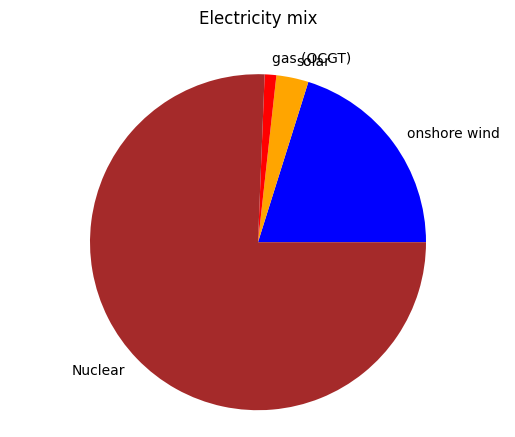

In [39]:
labels = ['onshore wind', 'solar', 'gas (OCGT)', 'Nuclear' ]
sizes = [network.generators_t.p['onshorewind'].sum(),
         network.generators_t.p['solar'].sum(),
         network.generators_t.p['OCGT'].sum(),
         network.generators_t.p['nuclear'].sum()]

colors = ['blue', 'orange', 'red', 'brown']

plt.pie(sizes,
        colors=colors,
        labels=labels,
        wedgeprops={'linewidth':0})
plt.axis('equal')

plt.title('Electricity mix', y=1.07)

## Addition of storage unit

In [40]:
lifetime = 60
capital_cost_hydro = annuity(60, 0.07) * 1994 *10**3 
fixed_o_m = 16.46*10**3 # EUR/MW/yr

network.add("StorageUnit",
            "Pumped Hydro",
            bus="electricity bus",
            p_nom_extendable=True,
            max_hours=11,
            efficiency_store=0.95,
            efficiency_dispatch=0.85,
            capital_cost=capital_cost_hydro + fixed_o_m,
            overwrite=True)